# Exploratory SNA, chapter 3


This notebook provides a Python transcription of the analyses presented in Chapter 3 of the book: Wouter de Nooy / Andrej Mrvar / Vladimir Batagelj, _Exploratory Social Network Analysis with Pajek_, Third edition, Cambridge: Cambridge University Press, 2018. 


It reuses the same data about visiting relations between families living in haciendas (farms).

The cohesive subgroups are compared to six family–friendship groupings defined by researchers.




In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
import pprint as pprint

In [2]:
# https://networkx.org/documentation/stable/install.html
import networkx as nx

#### https://ipycytoscape.readthedocs.io/en/latest/installing.html
# import ipycytoscape as cy

In [3]:
### Open a Pajek file

f = '../data/Chapter3/Attiro.net'
G = nx.read_pajek(f)

## MultiDiGraph: Directed graphs with self loops and parallel edges
# https://networkx.org/documentation/stable/reference/classes/multidigraph.html#networkx.MultiDiGraph
print(type(G))

<class 'networkx.classes.multidigraph.MultiDiGraph'>


In [4]:
### Inspect properties of nodes and edges
print(list(G.nodes.data())[:5])
print('-')
## Noter le dernier doublon de relations
print(list(G.edges.data())[-5:])

[('f1', {'id': '1', 'x': 0.3453, 'y': 0.6256, 'shape': '0.5000'}), ('f2', {'id': '2', 'x': 0.4557, 'y': 0.672, 'shape': '0.5000'}), ('f3', {'id': '3', 'x': 0.5077, 'y': 0.7262, 'shape': '0.5000'}), ('f4', {'id': '4', 'x': 0.4794, 'y': 0.394, 'shape': '0.5000'}), ('f6', {'id': '5', 'x': 0.4687, 'y': 0.5065, 'shape': '0.5000'})]
-
[('f97', 'f58', {'weight': 1.0}), ('f97', 'f88', {'weight': 1.0}), ('f98', 'f99', {'weight': 2.0}), ('f98', 'f41', {'weight': 2.0}), ('f99', 'f98', {'weight': 2.0})]


In [5]:
### Visiting relation:
# 1: ordinary
# 2: kin
# 3: ritual kin
l=[e[2]['weight'] for e in G.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

1.0    118
2.0     37
3.0      6
dtype: int64


In [6]:
### Remove the attributes listed below from all nodes
attrs_to_remove = ['x', 'y', 'shape']

for node in G.nodes():
    for attr in attrs_to_remove:
        if attr in G.nodes[node]:
            del G.nodes[node][attr]


In [7]:
### List of nodes' identifiers
nodes = list(G.nodes.keys())
nodes[:3]

['f1', 'f2', 'f3']

In [8]:
### Open the clusters file and zip it together with the 
# nodes' identifiers (they are in the same ordre and samel length)
f='../data/Chapter3/Attiro_grouping.clu'
cluster= pd.read_csv(f)
l = list(cluster["*Vertices 60"])
ln = list(zip(nodes,l))
print(ln)


[('f1', 0), ('f2', 0), ('f3', 0), ('f4', 0), ('f6', 10), ('f7', 4), ('f9', 4), ('f11', 4), ('f18', 4), ('f33', 0), ('f35', 4), ('f36', 0), ('f37', 0), ('f41', 7), ('f42', 0), ('f43', 7), ('f44', 0), ('f45', 0), ('f46', 5), ('f47', 5), ('f48', 10), ('f49', 4), ('f51', 4), ('f52', 4), ('f53', 4), ('f56', 0), ('f58', 5), ('f59', 5), ('f61', 10), ('f62', 1), ('f63', 5), ('f65a', 0), ('f65b', 10), ('f67', 0), ('f68', 0), ('f70', 0), ('f71', 1), ('f72', 1), ('f73', 10), ('f74', 0), ('f75', 0), ('f76', 0), ('f77', 0), ('f78', 0), ('f79', 0), ('f81', 0), ('f82', 10), ('f83', 10), ('f84', 10), ('f85', 10), ('f86', 10), ('f87', 10), ('f88', 10), ('f90', 1), ('f91', 10), ('f92', 10), ('f93', 0), ('f97', 10), ('f98', 7), ('f99', 7)]


In [9]:
### Prepare the family clusters to add to the nodes
friends = dict([(d[0], {'friends': d[1]}) for d in ln])
print(friends)

{'f1': {'friends': 0}, 'f2': {'friends': 0}, 'f3': {'friends': 0}, 'f4': {'friends': 0}, 'f6': {'friends': 10}, 'f7': {'friends': 4}, 'f9': {'friends': 4}, 'f11': {'friends': 4}, 'f18': {'friends': 4}, 'f33': {'friends': 0}, 'f35': {'friends': 4}, 'f36': {'friends': 0}, 'f37': {'friends': 0}, 'f41': {'friends': 7}, 'f42': {'friends': 0}, 'f43': {'friends': 7}, 'f44': {'friends': 0}, 'f45': {'friends': 0}, 'f46': {'friends': 5}, 'f47': {'friends': 5}, 'f48': {'friends': 10}, 'f49': {'friends': 4}, 'f51': {'friends': 4}, 'f52': {'friends': 4}, 'f53': {'friends': 4}, 'f56': {'friends': 0}, 'f58': {'friends': 5}, 'f59': {'friends': 5}, 'f61': {'friends': 10}, 'f62': {'friends': 1}, 'f63': {'friends': 5}, 'f65a': {'friends': 0}, 'f65b': {'friends': 10}, 'f67': {'friends': 0}, 'f68': {'friends': 0}, 'f70': {'friends': 0}, 'f71': {'friends': 1}, 'f72': {'friends': 1}, 'f73': {'friends': 10}, 'f74': {'friends': 0}, 'f75': {'friends': 0}, 'f76': {'friends': 0}, 'f77': {'friends': 0}, 'f78': {'f

In [10]:
### Add the family clusters to the nodes
nx.set_node_attributes(G, friends)
print(list(G.nodes.data())[:3])

[('f1', {'id': '1', 'friends': 0}), ('f2', {'id': '2', 'friends': 0}), ('f3', {'id': '3', 'friends': 0})]


0     23
1      4
4      9
5      5
7      4
10    15
dtype: int64


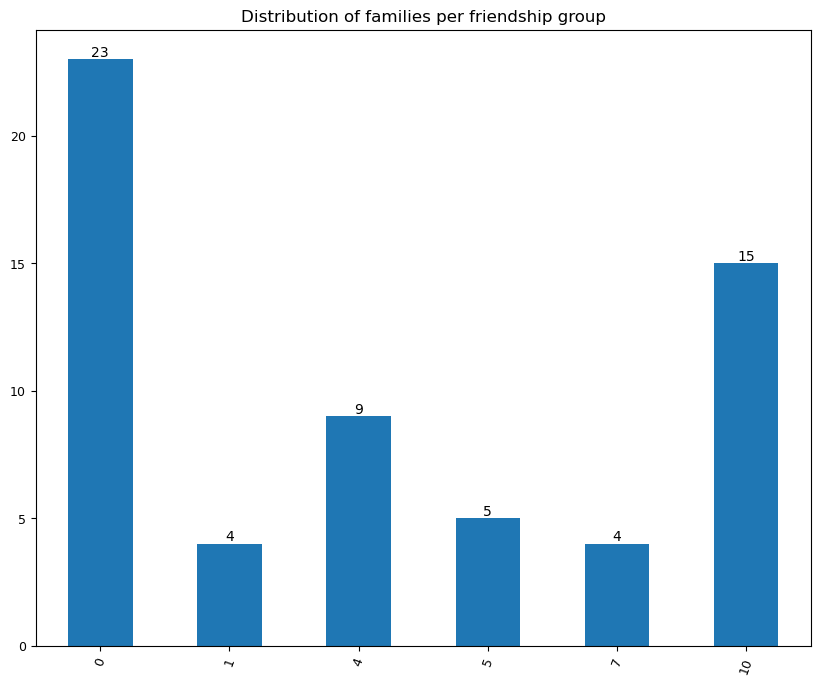

In [11]:
### Group and count families belonging to the same friends group
l = [n[1]['friends'] for n in G.nodes.data()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()

## there are families missing, cf. the identifiers
print(grouped)

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [12]:
colors = [
     "#6699CC",  # Sky Blue
    "#FFC0CB",  # Light Pink
    "#FF99CC",  # Pastel Pink
    "#FF69B4",  # Hot Pink
    "#FF33CC",  # Bright Pink
    "#CC33CC",  # Pastel Purple
    "#CC66CC",  # Light Purple
    "#00CCCC",  # Pale Turquoise
    "#33CCFF",  # Light Blue
    "#9966CC",  # Soft Purple
    "#00CC66",  # Mint Green
]

In [13]:
node_colors = [colors[G.nodes[n]['friends']] for n in G.nodes]
print(node_colors[:3])

['#6699CC', '#6699CC', '#6699CC']


In [14]:
print(list(G.nodes.data())[10:20])

[('f35', {'id': '11', 'friends': 4}), ('f36', {'id': '12', 'friends': 0}), ('f37', {'id': '13', 'friends': 0}), ('f41', {'id': '14', 'friends': 7}), ('f42', {'id': '15', 'friends': 0}), ('f43', {'id': '16', 'friends': 7}), ('f44', {'id': '17', 'friends': 0}), ('f45', {'id': '18', 'friends': 0}), ('f46', {'id': '19', 'friends': 5}), ('f47', {'id': '20', 'friends': 5})]


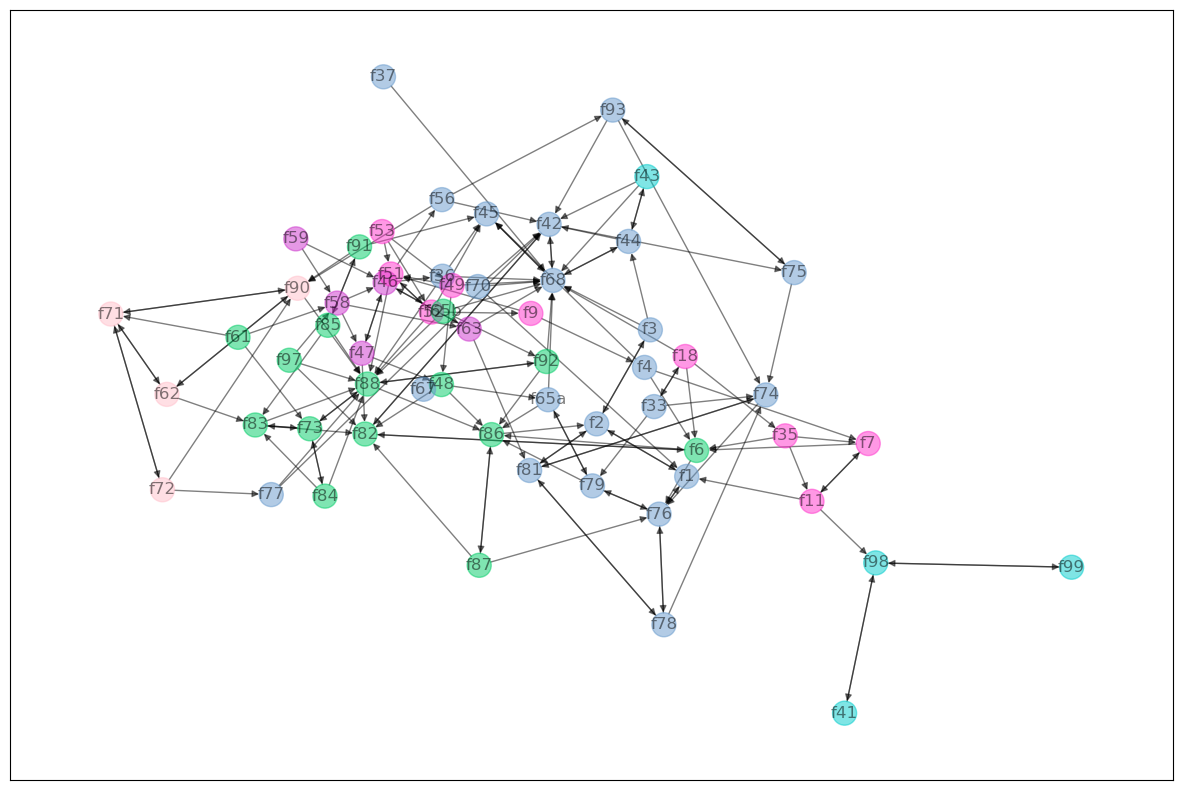

In [15]:
### Draw the network


plt.figure(figsize = (15,10))
pos = nx.kamada_kawai_layout(G)
nx.draw_networkx(G, pos, node_color=node_colors, alpha=0.5)


In [16]:
filtered_edges = [(u, v) for u,v,e in G.edges(data=True) if e['weight'] == 2.0]
filtered_edges[:3]


[('f4', 'f45'), ('f4', 'f7'), ('f37', 'f68')]

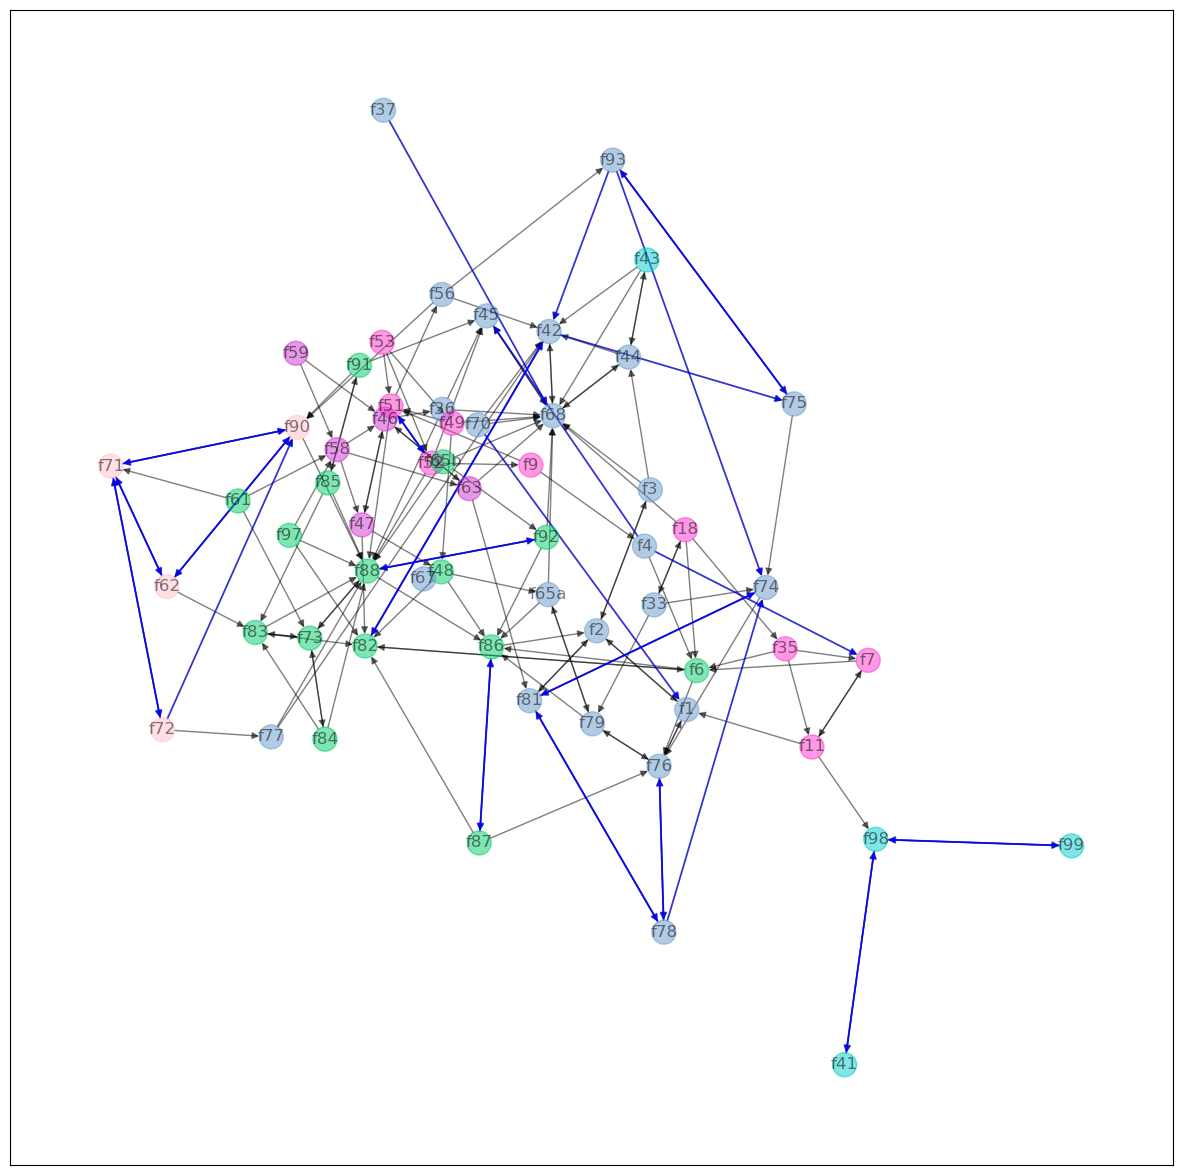

In [17]:

plt.figure(figsize = (15,15))
pos = nx.kamada_kawai_layout(G, scale=0.12)
#pos=nx.spring_layout(G, k=0.2, threshold=0.01)

fe = filtered_edges
c = 'blue'
nx.draw_networkx(G, pos, node_color=node_colors, alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=fe, width=1.3, edge_color=c, alpha=0.6)

plt.show()

In [18]:
### Graph density
d = nx.density(G)
print(d)

0.045480225988700565


In [19]:
print(G.in_degree())

[('f1', 4), ('f2', 4), ('f3', 1), ('f4', 1), ('f6', 5), ('f7', 3), ('f9', 1), ('f11', 2), ('f18', 1), ('f33', 1), ('f35', 1), ('f36', 1), ('f37', 0), ('f41', 1), ('f42', 8), ('f43', 1), ('f44', 3), ('f45', 5), ('f46', 4), ('f47', 2), ('f48', 2), ('f49', 1), ('f51', 4), ('f52', 2), ('f53', 0), ('f56', 1), ('f58', 3), ('f59', 0), ('f61', 0), ('f62', 2), ('f63', 2), ('f65a', 2), ('f65b', 0), ('f67', 0), ('f68', 14), ('f70', 0), ('f71', 4), ('f72', 1), ('f73', 4), ('f74', 5), ('f75', 2), ('f76', 6), ('f77', 1), ('f78', 2), ('f79', 3), ('f81', 4), ('f82', 7), ('f83', 4), ('f84', 1), ('f85', 1), ('f86', 7), ('f87', 1), ('f88', 12), ('f90', 5), ('f91', 1), ('f92', 2), ('f93', 2), ('f97', 0), ('f98', 3), ('f99', 1)]


In [20]:
indegree = dict([(d[0], {'indegree': d[1]}) for d in G.in_degree()])
print(indegree)

{'f1': {'indegree': 4}, 'f2': {'indegree': 4}, 'f3': {'indegree': 1}, 'f4': {'indegree': 1}, 'f6': {'indegree': 5}, 'f7': {'indegree': 3}, 'f9': {'indegree': 1}, 'f11': {'indegree': 2}, 'f18': {'indegree': 1}, 'f33': {'indegree': 1}, 'f35': {'indegree': 1}, 'f36': {'indegree': 1}, 'f37': {'indegree': 0}, 'f41': {'indegree': 1}, 'f42': {'indegree': 8}, 'f43': {'indegree': 1}, 'f44': {'indegree': 3}, 'f45': {'indegree': 5}, 'f46': {'indegree': 4}, 'f47': {'indegree': 2}, 'f48': {'indegree': 2}, 'f49': {'indegree': 1}, 'f51': {'indegree': 4}, 'f52': {'indegree': 2}, 'f53': {'indegree': 0}, 'f56': {'indegree': 1}, 'f58': {'indegree': 3}, 'f59': {'indegree': 0}, 'f61': {'indegree': 0}, 'f62': {'indegree': 2}, 'f63': {'indegree': 2}, 'f65a': {'indegree': 2}, 'f65b': {'indegree': 0}, 'f67': {'indegree': 0}, 'f68': {'indegree': 14}, 'f70': {'indegree': 0}, 'f71': {'indegree': 4}, 'f72': {'indegree': 1}, 'f73': {'indegree': 4}, 'f74': {'indegree': 5}, 'f75': {'indegree': 2}, 'f76': {'indegree':

In [21]:
nx.set_node_attributes(G, indegree)
print(list(G.nodes.data())[:3])

[('f1', {'id': '1', 'friends': 0, 'indegree': 4}), ('f2', {'id': '2', 'friends': 0, 'indegree': 4}), ('f3', {'id': '3', 'friends': 0, 'indegree': 1})]


In [22]:
node_size=[e[1]['indegree']*100 for e in G.nodes.data()]
print(node_size[:3])

[400, 400, 100]


In [23]:
### Indegree mean value
ds=[d[1] for d in G.in_degree()]
print(round(sum(ds)/len(ds),ndigits=2))

2.68


0      8
1     18
2     11
3      5
4      8
5      4
6      1
7      2
8      1
12     1
14     1
dtype: int64


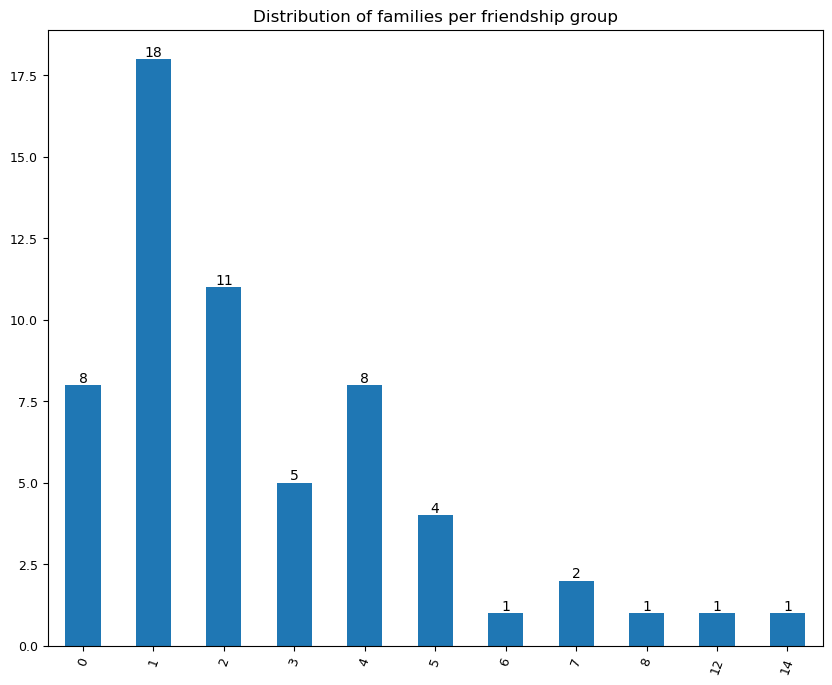

In [24]:
### Group and count families belonging to the same friends group
l = [d[1] for d in G.in_degree()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()

## there are families missing, cf. the identifiers
print(grouped)

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


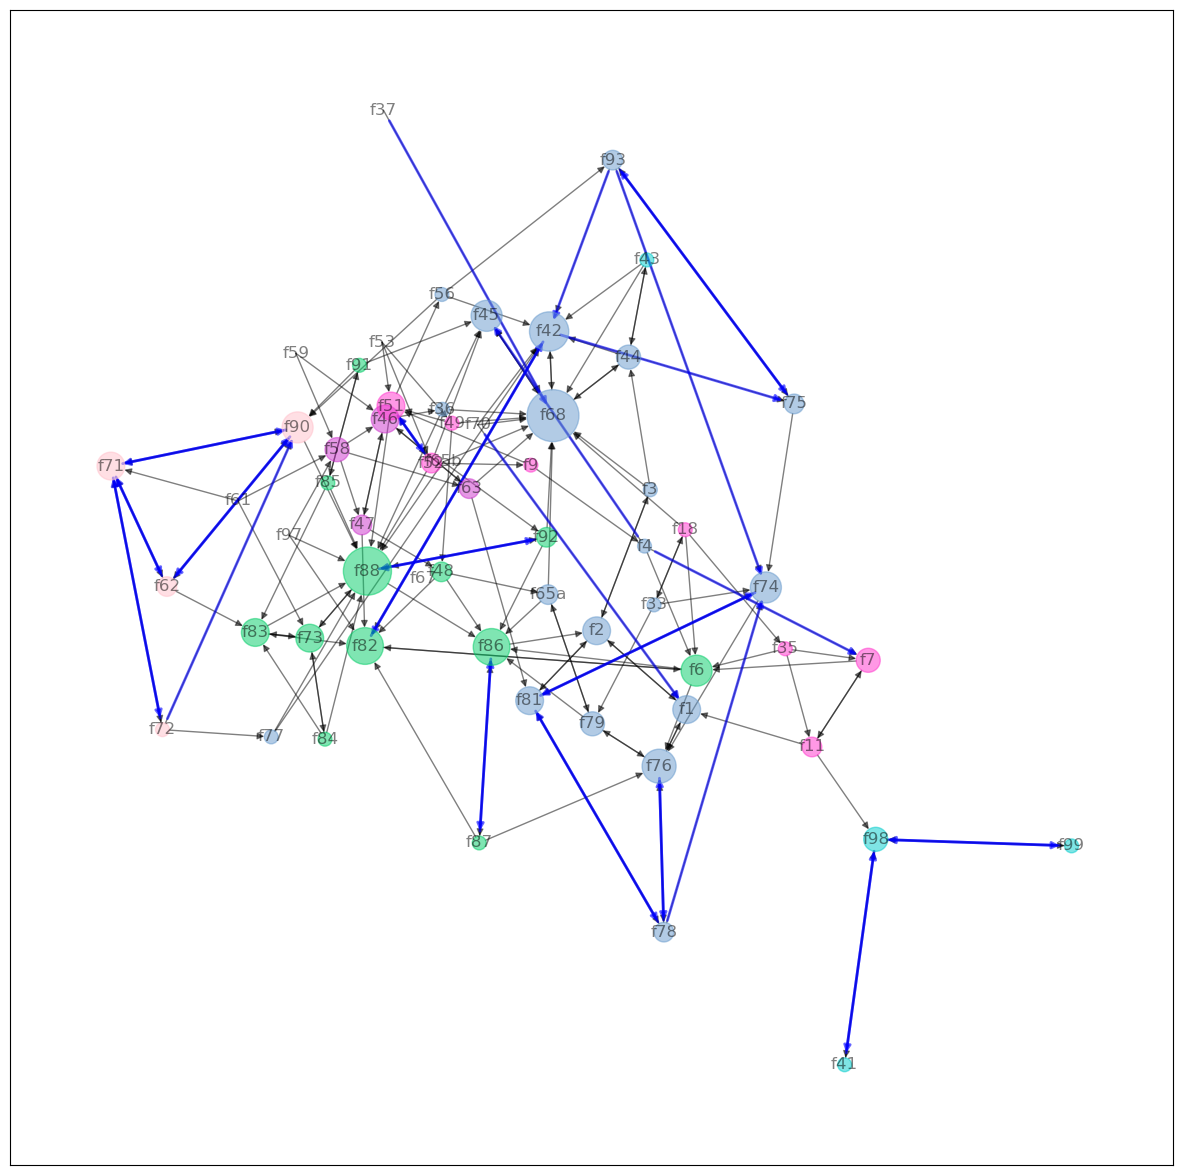

In [25]:

plt.figure(figsize = (15,15))
pos = nx.kamada_kawai_layout(G, scale=0.12)
#pos=nx.spring_layout(G, k=0.2, threshold=0.01)

fe = filtered_edges
c = 'blue'
nx.draw_networkx(G, pos, node_color=node_colors, 
                 node_size=node_size, alpha=0.5)
nx.draw_networkx_edges(G, pos, edgelist=fe, width=2, edge_color=c, alpha=0.6)

plt.show()

In [26]:
outdegree = dict([(d[0], {'outdegree': d[1]}) for d in G.out_degree()])
print(outdegree)

{'f1': {'outdegree': 2}, 'f2': {'outdegree': 3}, 'f3': {'outdegree': 3}, 'f4': {'outdegree': 3}, 'f6': {'outdegree': 3}, 'f7': {'outdegree': 2}, 'f9': {'outdegree': 2}, 'f11': {'outdegree': 3}, 'f18': {'outdegree': 4}, 'f33': {'outdegree': 3}, 'f35': {'outdegree': 3}, 'f36': {'outdegree': 3}, 'f37': {'outdegree': 1}, 'f41': {'outdegree': 1}, 'f42': {'outdegree': 3}, 'f43': {'outdegree': 3}, 'f44': {'outdegree': 3}, 'f45': {'outdegree': 1}, 'f46': {'outdegree': 3}, 'f47': {'outdegree': 3}, 'f48': {'outdegree': 3}, 'f49': {'outdegree': 3}, 'f51': {'outdegree': 3}, 'f52': {'outdegree': 4}, 'f53': {'outdegree': 3}, 'f56': {'outdegree': 3}, 'f58': {'outdegree': 3}, 'f59': {'outdegree': 2}, 'f61': {'outdegree': 3}, 'f62': {'outdegree': 3}, 'f63': {'outdegree': 3}, 'f65a': {'outdegree': 3}, 'f65b': {'outdegree': 3}, 'f67': {'outdegree': 0}, 'f68': {'outdegree': 3}, 'f70': {'outdegree': 3}, 'f71': {'outdegree': 3}, 'f72': {'outdegree': 3}, 'f73': {'outdegree': 3}, 'f74': {'outdegree': 2}, 'f75

In [27]:
nx.set_node_attributes(G, outdegree)
print(list(G.nodes.data())[:3])

[('f1', {'id': '1', 'friends': 0, 'indegree': 4, 'outdegree': 2}), ('f2', {'id': '2', 'friends': 0, 'indegree': 4, 'outdegree': 3}), ('f3', {'id': '3', 'friends': 0, 'indegree': 1, 'outdegree': 3})]


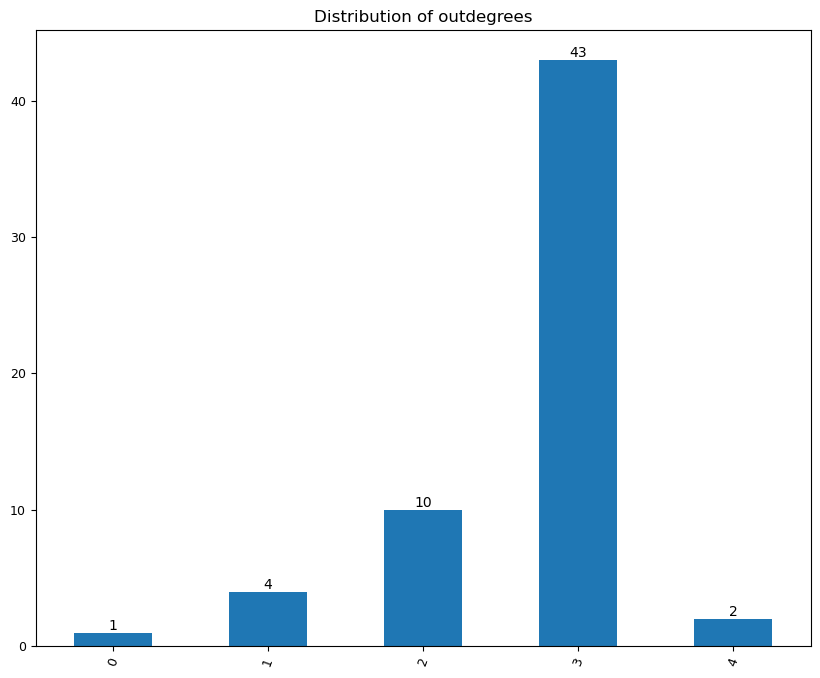

In [28]:
### Group and count families belonging to the same friends group
l = [d[1] for d in G.out_degree()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()


ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of outdegrees')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [29]:
ld = [ n[1]['indegree']-n[1]['outdegree'] for n in G.nodes.data()]
print(ld[:3])

[2, 1, -2]


-3      6
-2     15
-1     12
 0      7
 1      9
 2      3
 3      2
 4      1
 5      3
 9      1
 11     1
dtype: int64


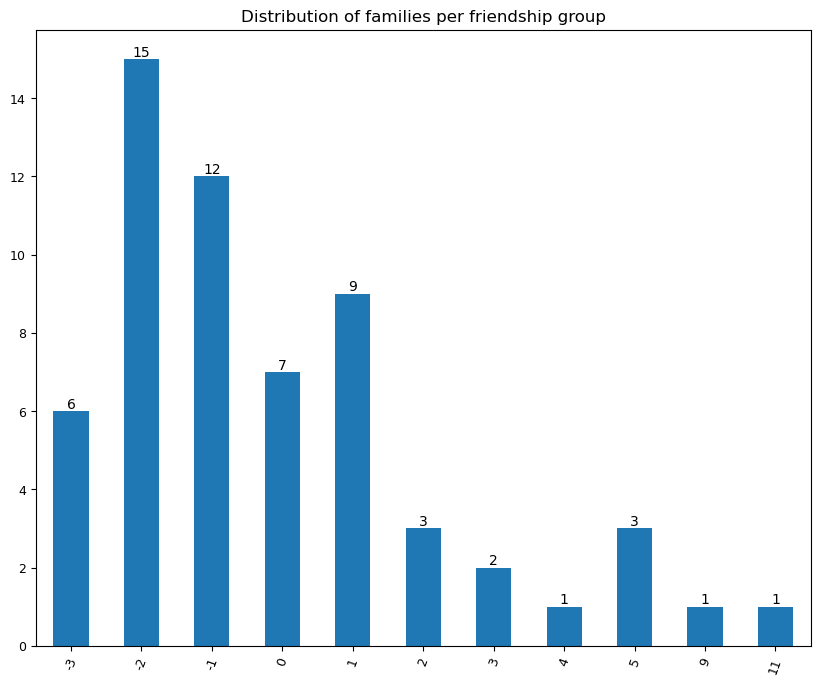

In [30]:
### Group and count families belonging to the same friends group
ls = pd.Series(ld)
grouped = ls.groupby(ls).size()

## there are families missing, cf. the identifiers
print(grouped)

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [31]:
label_colors = {}
for n in G.nodes.data():
    if n[1]['indegree']-n[1]['outdegree'] < 0:
        label_colors.update({n[0]:'red'})
    elif n[1]['indegree']-n[1]['outdegree'] < 3:
        label_colors.update({n[0]:'grey'})
    else:
        label_colors.update({n[0]:'black'})


print(label_colors)

{'f1': 'grey', 'f2': 'grey', 'f3': 'red', 'f4': 'red', 'f6': 'grey', 'f7': 'grey', 'f9': 'red', 'f11': 'red', 'f18': 'red', 'f33': 'red', 'f35': 'red', 'f36': 'red', 'f37': 'red', 'f41': 'grey', 'f42': 'black', 'f43': 'red', 'f44': 'grey', 'f45': 'black', 'f46': 'grey', 'f47': 'red', 'f48': 'red', 'f49': 'red', 'f51': 'grey', 'f52': 'red', 'f53': 'red', 'f56': 'red', 'f58': 'grey', 'f59': 'red', 'f61': 'red', 'f62': 'red', 'f63': 'red', 'f65a': 'red', 'f65b': 'red', 'f67': 'grey', 'f68': 'black', 'f70': 'red', 'f71': 'grey', 'f72': 'red', 'f73': 'grey', 'f74': 'black', 'f75': 'grey', 'f76': 'black', 'f77': 'red', 'f78': 'red', 'f79': 'grey', 'f81': 'grey', 'f82': 'black', 'f83': 'grey', 'f84': 'red', 'f85': 'red', 'f86': 'black', 'f87': 'red', 'f88': 'black', 'f90': 'grey', 'f91': 'red', 'f92': 'red', 'f93': 'red', 'f97': 'red', 'f98': 'grey', 'f99': 'grey'}


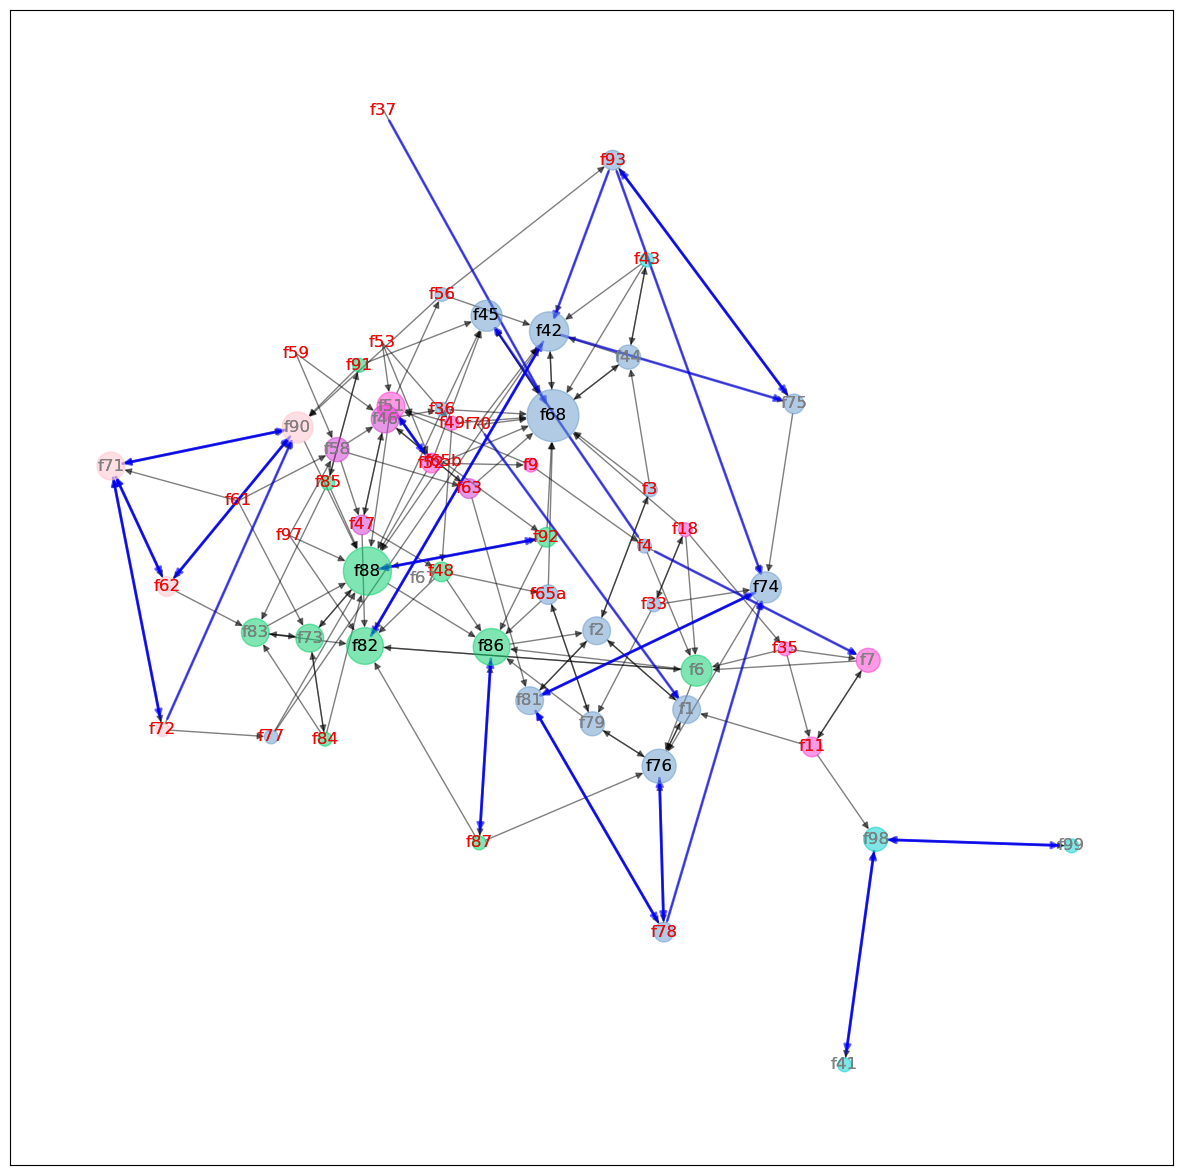

In [32]:

plt.figure(figsize = (15,15))
pos = nx.kamada_kawai_layout(G, scale=0.12)
#pos=nx.spring_layout(G, k=0.2, threshold=0.01)

fe = filtered_edges
c = 'blue'
nx.draw_networkx(G, pos, node_color=node_colors, 
                 node_size=node_size, alpha=0.5)
nx.draw_networkx_labels(G, pos, font_color=label_colors)
nx.draw_networkx_edges(G, pos, edgelist=fe, width=2, edge_color=c, alpha=0.6)

plt.show()

## Change to undirected network

In [33]:
### Graph properties
print(G.number_of_nodes(), G.number_of_edges(), nx.is_strongly_connected(G), 
      '\n', G.edges.data())


60 161 False 
 [('f1', 'f2', {'weight': 1.0}), ('f1', 'f76', {'weight': 1.0}), ('f2', 'f81', {'weight': 1.0}), ('f2', 'f3', {'weight': 1.0}), ('f2', 'f1', {'weight': 1.0}), ('f3', 'f2', {'weight': 1.0}), ('f3', 'f68', {'weight': 1.0}), ('f3', 'f44', {'weight': 1.0}), ('f4', 'f45', {'weight': 2.0}), ('f4', 'f6', {'weight': 1.0}), ('f4', 'f7', {'weight': 2.0}), ('f6', 'f82', {'weight': 3.0}), ('f6', 'f76', {'weight': 1.0}), ('f6', 'f86', {'weight': 1.0}), ('f7', 'f11', {'weight': 1.0}), ('f7', 'f6', {'weight': 3.0}), ('f9', 'f4', {'weight': 1.0}), ('f9', 'f51', {'weight': 1.0}), ('f11', 'f1', {'weight': 1.0}), ('f11', 'f98', {'weight': 1.0}), ('f11', 'f7', {'weight': 1.0}), ('f18', 'f68', {'weight': 1.0}), ('f18', 'f6', {'weight': 1.0}), ('f18', 'f35', {'weight': 1.0}), ('f18', 'f33', {'weight': 1.0}), ('f33', 'f74', {'weight': 1.0}), ('f33', 'f18', {'weight': 1.0}), ('f33', 'f79', {'weight': 1.0}), ('f35', 'f11', {'weight': 1.0}), ('f35', 'f7', {'weight': 1.0}), ('f35', 'f6', {'weight':

In [34]:
### Visiting relation:
# 1: ordinary
# 2: kin
# 3: ritual kin
l=[e[2]['weight'] for e in G.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

1.0    118
2.0     37
3.0      6
dtype: int64


In [35]:
### create weighted graph from M
## Autres méthodes, sans compter les doubles:
# Gu = G.to_undirected()
# Gu = nx.Graph(Gu)
GG = nx.Graph()
for u,v,data in G.edges.data():
    w = data['weight']
    if GG.has_edge(u,v):
        GG[u][v]['n_edges'] += 1
    else:
        GG.add_edge(u, v, n_edges=1, weight=w)

print(nx.density(GG))
print(GG.edges.data())


0.07481005260081823
[('f1', 'f2', {'n_edges': 2, 'weight': 1.0}), ('f1', 'f76', {'n_edges': 2, 'weight': 1.0}), ('f1', 'f11', {'n_edges': 1, 'weight': 1.0}), ('f1', 'f70', {'n_edges': 1, 'weight': 2.0}), ('f2', 'f81', {'n_edges': 2, 'weight': 1.0}), ('f2', 'f3', {'n_edges': 2, 'weight': 1.0}), ('f2', 'f86', {'n_edges': 1, 'weight': 1.0}), ('f76', 'f6', {'n_edges': 1, 'weight': 1.0}), ('f76', 'f74', {'n_edges': 1, 'weight': 1.0}), ('f76', 'f79', {'n_edges': 2, 'weight': 1.0}), ('f76', 'f78', {'n_edges': 2, 'weight': 2.0}), ('f76', 'f87', {'n_edges': 1, 'weight': 1.0}), ('f81', 'f63', {'n_edges': 1, 'weight': 1.0}), ('f81', 'f74', {'n_edges': 2, 'weight': 2.0}), ('f81', 'f78', {'n_edges': 2, 'weight': 2.0}), ('f3', 'f68', {'n_edges': 1, 'weight': 1.0}), ('f3', 'f44', {'n_edges': 1, 'weight': 1.0}), ('f68', 'f18', {'n_edges': 1, 'weight': 1.0}), ('f68', 'f36', {'n_edges': 1, 'weight': 1.0}), ('f68', 'f37', {'n_edges': 1, 'weight': 2.0}), ('f68', 'f42', {'n_edges': 2, 'weight': 1.0}), ('f6

In [36]:
### Visiting relation:
# 1: ordinary
# 2: kin
# 3: ritual kin
l=[e[2]['weight'] for e in GG.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

1.0    101
2.0     23
3.0      4
dtype: int64


In [37]:
### 
l=[e[2]['n_edges'] for e in GG.edges.data()]
ls=pd.Series(l)
print(ls.groupby(ls).size())

1    95
2    33
dtype: int64


In [38]:
### Graph properties
# Note that the not connected vertex of G 
# isn't any more in the graph
print(GG.number_of_nodes(), GG.number_of_edges(), 
      nx.is_connected(GG), 
      '\n', GG.edges.data())


59 128 True 
 [('f1', 'f2', {'n_edges': 2, 'weight': 1.0}), ('f1', 'f76', {'n_edges': 2, 'weight': 1.0}), ('f1', 'f11', {'n_edges': 1, 'weight': 1.0}), ('f1', 'f70', {'n_edges': 1, 'weight': 2.0}), ('f2', 'f81', {'n_edges': 2, 'weight': 1.0}), ('f2', 'f3', {'n_edges': 2, 'weight': 1.0}), ('f2', 'f86', {'n_edges': 1, 'weight': 1.0}), ('f76', 'f6', {'n_edges': 1, 'weight': 1.0}), ('f76', 'f74', {'n_edges': 1, 'weight': 1.0}), ('f76', 'f79', {'n_edges': 2, 'weight': 1.0}), ('f76', 'f78', {'n_edges': 2, 'weight': 2.0}), ('f76', 'f87', {'n_edges': 1, 'weight': 1.0}), ('f81', 'f63', {'n_edges': 1, 'weight': 1.0}), ('f81', 'f74', {'n_edges': 2, 'weight': 2.0}), ('f81', 'f78', {'n_edges': 2, 'weight': 2.0}), ('f3', 'f68', {'n_edges': 1, 'weight': 1.0}), ('f3', 'f44', {'n_edges': 1, 'weight': 1.0}), ('f68', 'f18', {'n_edges': 1, 'weight': 1.0}), ('f68', 'f36', {'n_edges': 1, 'weight': 1.0}), ('f68', 'f37', {'n_edges': 1, 'weight': 2.0}), ('f68', 'f42', {'n_edges': 2, 'weight': 1.0}), ('f68', 'f

### Add the existing node attributes and the degree


Add the graph G node attributes to the new GG graph

In [39]:
na = dict(G.nodes(data=True))
print(na)

{'f1': {'id': '1', 'friends': 0, 'indegree': 4, 'outdegree': 2}, 'f2': {'id': '2', 'friends': 0, 'indegree': 4, 'outdegree': 3}, 'f3': {'id': '3', 'friends': 0, 'indegree': 1, 'outdegree': 3}, 'f4': {'id': '4', 'friends': 0, 'indegree': 1, 'outdegree': 3}, 'f6': {'id': '5', 'friends': 10, 'indegree': 5, 'outdegree': 3}, 'f7': {'id': '6', 'friends': 4, 'indegree': 3, 'outdegree': 2}, 'f9': {'id': '7', 'friends': 4, 'indegree': 1, 'outdegree': 2}, 'f11': {'id': '8', 'friends': 4, 'indegree': 2, 'outdegree': 3}, 'f18': {'id': '9', 'friends': 4, 'indegree': 1, 'outdegree': 4}, 'f33': {'id': '10', 'friends': 0, 'indegree': 1, 'outdegree': 3}, 'f35': {'id': '11', 'friends': 4, 'indegree': 1, 'outdegree': 3}, 'f36': {'id': '12', 'friends': 0, 'indegree': 1, 'outdegree': 3}, 'f37': {'id': '13', 'friends': 0, 'indegree': 0, 'outdegree': 1}, 'f41': {'id': '14', 'friends': 7, 'indegree': 1, 'outdegree': 1}, 'f42': {'id': '15', 'friends': 0, 'indegree': 8, 'outdegree': 3}, 'f43': {'id': '16', 'fri

In [40]:
nx.set_node_attributes(GG, na)
print(list(G.nodes(data=True))[:3])

[('f1', {'id': '1', 'friends': 0, 'indegree': 4, 'outdegree': 2}), ('f2', {'id': '2', 'friends': 0, 'indegree': 4, 'outdegree': 3}), ('f3', {'id': '3', 'friends': 0, 'indegree': 1, 'outdegree': 3})]


In [41]:
# Calculate node degrees
node_degrees = dict(GG.degree())

# Add degree as a node attribute
for node, degree in node_degrees.items():
    GG.nodes[node]['degree'] = degree


In [42]:
print(list(GG.nodes.data())[:3])

[('f1', {'id': '1', 'friends': 0, 'indegree': 4, 'outdegree': 2, 'degree': 4}), ('f2', {'id': '2', 'friends': 0, 'indegree': 4, 'outdegree': 3, 'degree': 4}), ('f76', {'id': '42', 'friends': 0, 'indegree': 6, 'outdegree': 3, 'degree': 6})]


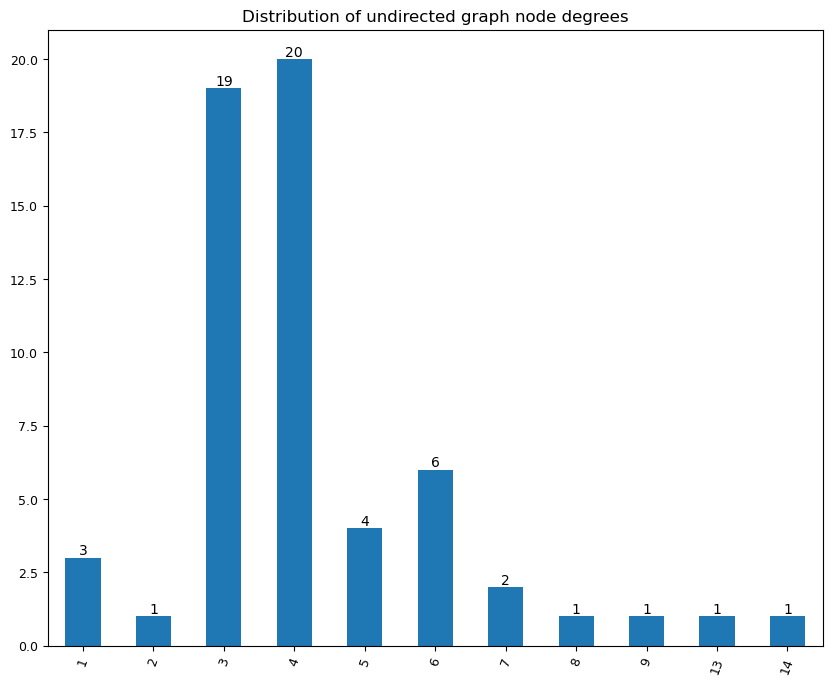

In [43]:
### Group and count degrees
l = [n[1]['degree'] for n in GG.nodes.data()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()

ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of undirected graph node degrees')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [44]:
k_core_decomposition = nx.core_number(GG)
print(k_core_decomposition)

{'f1': 3, 'f2': 3, 'f76': 3, 'f81': 3, 'f3': 3, 'f68': 3, 'f44': 3, 'f4': 3, 'f45': 3, 'f6': 3, 'f7': 3, 'f82': 3, 'f86': 3, 'f11': 3, 'f9': 3, 'f51': 3, 'f98': 1, 'f18': 3, 'f35': 3, 'f33': 3, 'f74': 3, 'f79': 3, 'f36': 3, 'f88': 3, 'f37': 1, 'f41': 1, 'f42': 3, 'f75': 3, 'f43': 3, 'f46': 3, 'f63': 3, 'f47': 3, 'f48': 3, 'f65a': 3, 'f49': 3, 'f56': 3, 'f52': 3, 'f53': 3, 'f90': 3, 'f93': 3, 'f58': 3, 'f59': 2, 'f61': 3, 'f71': 3, 'f73': 3, 'f62': 3, 'f83': 3, 'f65b': 3, 'f92': 3, 'f70': 3, 'f72': 3, 'f77': 3, 'f84': 3, 'f78': 3, 'f85': 3, 'f91': 3, 'f87': 3, 'f97': 3, 'f99': 1}


In [45]:
pprint.pprint(nx.onion_layers(GG))

{'f1': 5,
 'f11': 4,
 'f18': 5,
 'f2': 5,
 'f3': 4,
 'f33': 4,
 'f35': 5,
 'f36': 7,
 'f37': 1,
 'f4': 5,
 'f41': 1,
 'f42': 6,
 'f43': 4,
 'f44': 5,
 'f45': 6,
 'f46': 6,
 'f47': 6,
 'f48': 7,
 'f49': 5,
 'f51': 6,
 'f52': 5,
 'f53': 4,
 'f56': 6,
 'f58': 5,
 'f59': 3,
 'f6': 6,
 'f61': 4,
 'f62': 4,
 'f63': 6,
 'f65a': 6,
 'f65b': 4,
 'f68': 7,
 'f7': 5,
 'f70': 4,
 'f71': 5,
 'f72': 4,
 'f73': 5,
 'f74': 5,
 'f75': 4,
 'f76': 6,
 'f77': 4,
 'f78': 4,
 'f79': 5,
 'f81': 5,
 'f82': 7,
 'f83': 5,
 'f84': 4,
 'f85': 4,
 'f86': 7,
 'f87': 4,
 'f88': 6,
 'f9': 4,
 'f90': 5,
 'f91': 4,
 'f92': 5,
 'f93': 5,
 'f97': 4,
 'f98': 2,
 'f99': 1}


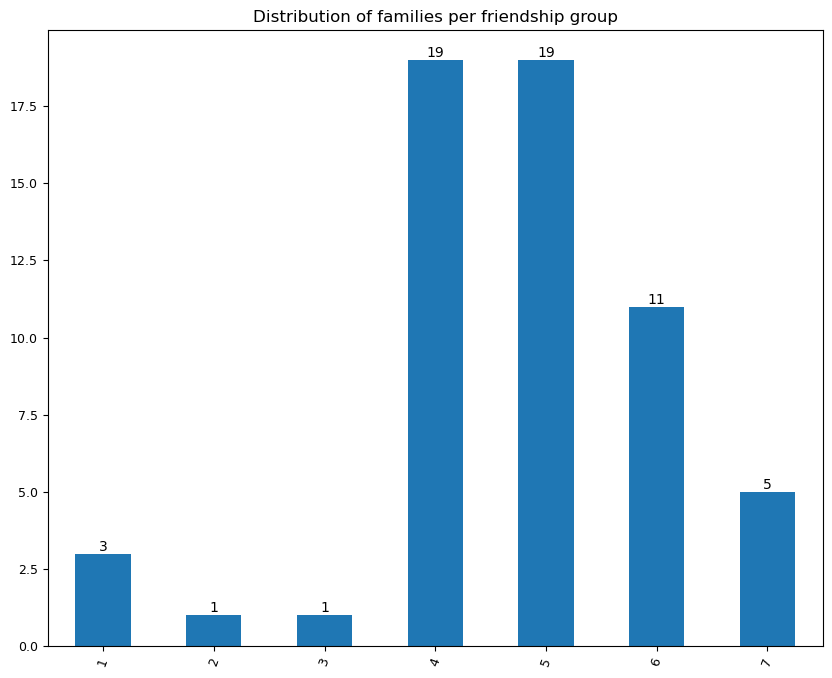

In [46]:
### Group and count families belonging to the same friends group
l = [v for k,v in nx.onion_layers(GG).items()]
ls = pd.Series(l)
grouped = ls.groupby(ls).size()


ax = grouped.plot.bar(stacked=True, rot=70, fontsize=9, figsize=(10,8))
plt.title('Distribution of families per friendship group')

## https://stackoverflow.com/questions/71320380/add-only-the-total-values-on-top-of-stacked-bars
ax.bar_label(ax.containers[-1])

plt.show()


In [47]:
ld = [ k  for k,v in nx.onion_layers(GG).items()  if v > 6]
print(ld)

['f68', 'f82', 'f86', 'f36', 'f48']


In [48]:
GS = GG.subgraph(ld)
print(nx.number_of_edges(GS))
print(GS.nodes.data())

3
[('f68', {'id': '35', 'friends': 0, 'indegree': 14, 'outdegree': 3, 'degree': 14}), ('f48', {'id': '21', 'friends': 10, 'indegree': 2, 'outdegree': 3, 'degree': 5}), ('f36', {'id': '12', 'friends': 0, 'indegree': 1, 'outdegree': 3, 'degree': 4}), ('f82', {'id': '47', 'friends': 10, 'indegree': 7, 'outdegree': 2, 'degree': 7}), ('f86', {'id': '51', 'friends': 10, 'indegree': 7, 'outdegree': 2, 'degree': 8})]


In [49]:
node_colors = [colors[GS.nodes[n]['friends']] for n in GS.nodes]
print(node_colors[:3])

['#6699CC', '#00CC66', '#6699CC']


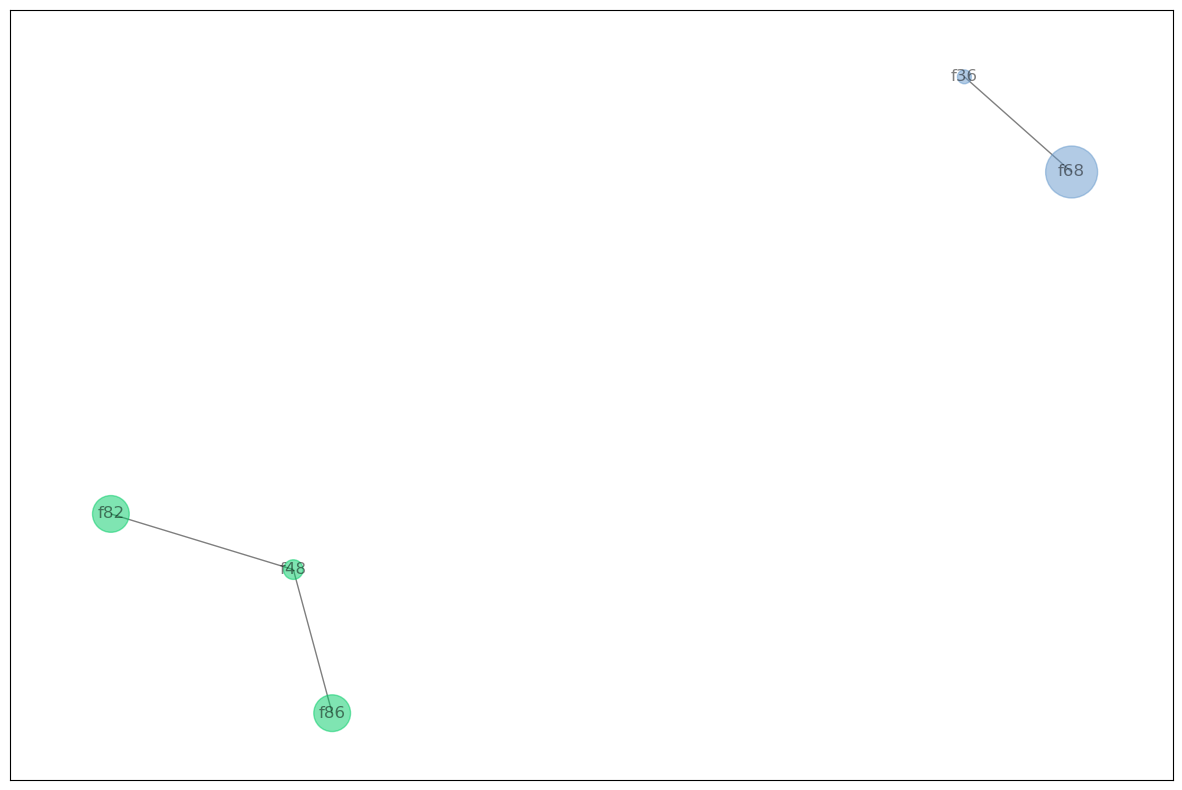

In [50]:
### Draw the network

node_size=[e[1]['indegree']*100 for e in GS.nodes.data()]

plt.figure(figsize = (15,10))
#pos = nx.kamada_kawai_layout(GS)
pos = nx.spring_layout(GS)
nx.draw_networkx(GS, pos, node_color=node_colors, 
                 node_size=node_size,alpha=0.5)
